In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("TASK 2: TECHNICAL INDICATORS - SMA, RSI, MACD")
print("="*60)
print("✅ Libraries imported!")

TASK 2: TECHNICAL INDICATORS - SMA, RSI, MACD
✅ Libraries imported!


In [3]:
# Load AAPL stock data
aapl = pd.read_csv('../data/raw/AAPL.csv')
aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl = aapl.sort_values('Date')
aapl['Daily_Return'] = aapl['Close'].pct_change() * 100

print(f"✅ Loaded {len(aapl)} days of AAPL data")
print(f"📅 Date range: {aapl['Date'].min()} to {aapl['Date'].max()}")
print(aapl[['Date', 'Close']].head(3))

✅ Loaded 3774 days of AAPL data
📅 Date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00
        Date     Close
0 2009-01-02  2.721686
1 2009-01-05  2.836553
2 2009-01-06  2.789767


In [4]:
# Calculate SMAs
aapl['SMA_20'] = aapl['Close'].rolling(window=20).mean()
aapl['SMA_50'] = aapl['Close'].rolling(window=50).mean()

latest = aapl.iloc[-1]
print(f"\n📊 SMA RESULTS:")
print(f"   Close: ${latest['Close']:.2f}")
print(f"   SMA 20: ${latest['SMA_20']:.2f}")
print(f"   SMA 50: ${latest['SMA_50']:.2f}")

if latest['SMA_20'] > latest['SMA_50']:
    print(f"   Signal: BULLISH (BUY)")
else:
    print(f"   Signal: BEARISH (SELL)")


📊 SMA RESULTS:
   Close: $190.73
   SMA 20: $192.49
   SMA 50: $184.81
   Signal: BULLISH (BUY)


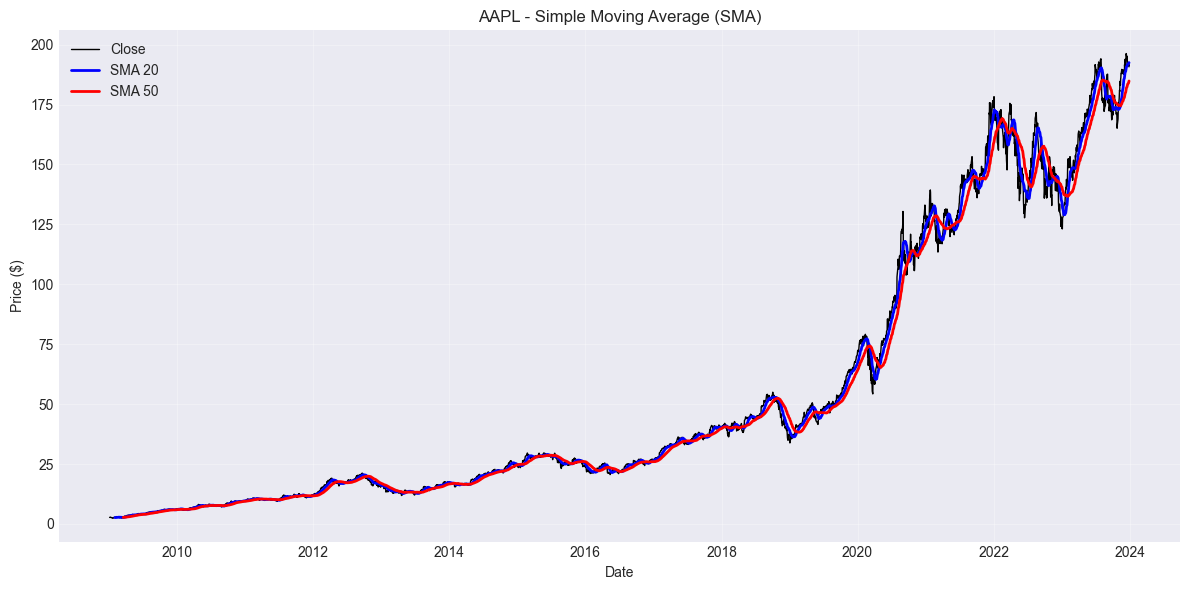

✅ SMA plot saved


In [5]:
plt.figure(figsize=(12, 6))
plt.plot(aapl['Date'], aapl['Close'], label='Close', linewidth=1, color='black')
plt.plot(aapl['Date'], aapl['SMA_20'], label='SMA 20', linewidth=2, color='blue')
plt.plot(aapl['Date'], aapl['SMA_50'], label='SMA 50', linewidth=2, color='red')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.title('AAPL - Simple Moving Average (SMA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/sma_indicator.png', dpi=150)
plt.show()
print("✅ SMA plot saved")

In [6]:
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

aapl['RSI_14'] = calculate_rsi(aapl['Close'])
print(f"📊 RSI: {aapl['RSI_14'].iloc[-1]:.1f}")

📊 RSI: 40.2


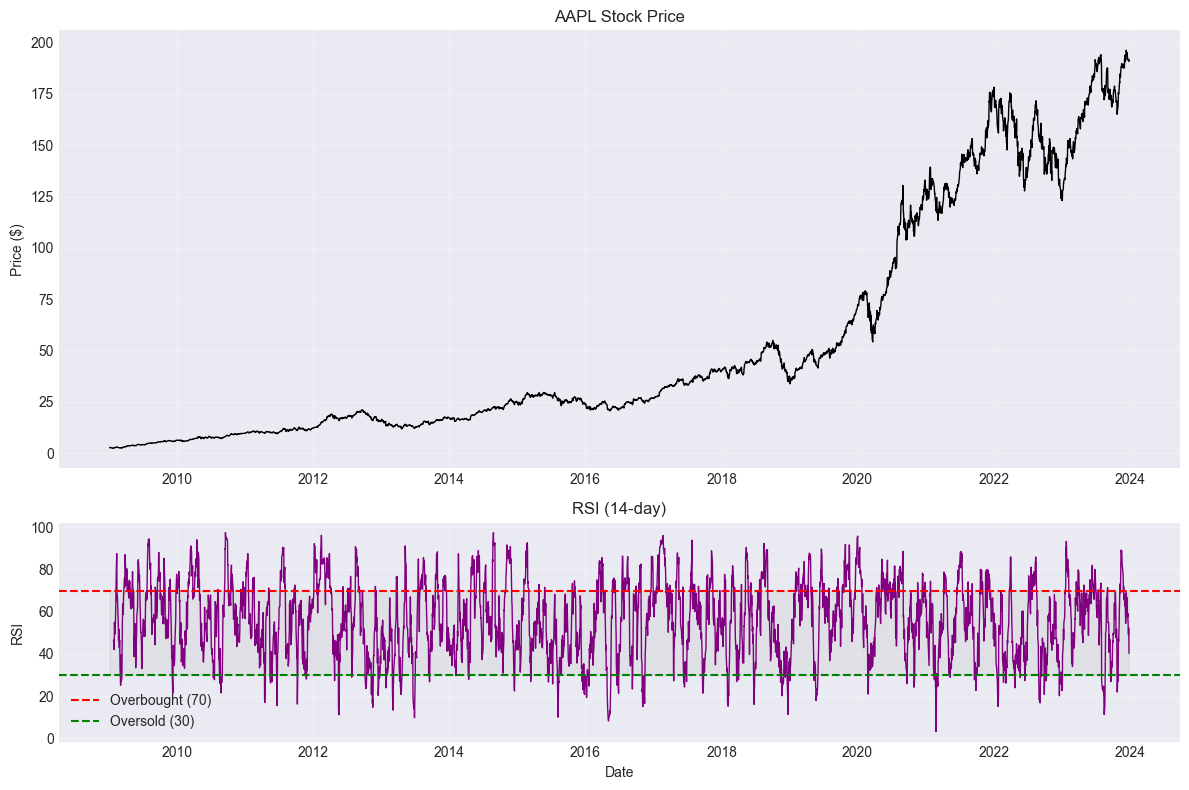

✅ RSI plot saved


In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1])

ax1.plot(aapl['Date'], aapl['Close'], color='black', linewidth=1)
ax1.set_ylabel('Price ($)')
ax1.set_title('AAPL Stock Price')
ax1.grid(True, alpha=0.3)

ax2.plot(aapl['Date'], aapl['RSI_14'], color='purple', linewidth=1)
ax2.axhline(y=70, color='red', linestyle='--', label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', label='Oversold (30)')
ax2.fill_between(aapl['Date'], 30, 70, alpha=0.1, color='gray')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_title('RSI (14-day)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/rsi_indicator.png', dpi=150)
plt.show()
print("✅ RSI plot saved")

In [8]:
# Calculate MACD
ema12 = aapl['Close'].ewm(span=12, adjust=False).mean()
ema26 = aapl['Close'].ewm(span=26, adjust=False).mean()
aapl['MACD'] = ema12 - ema26
aapl['Signal'] = aapl['MACD'].ewm(span=9, adjust=False).mean()
aapl['Histogram'] = aapl['MACD'] - aapl['Signal']

print(f"📊 MACD: {aapl['MACD'].iloc[-1]:.4f}")
print(f"   Signal: {aapl['Signal'].iloc[-1]:.4f}")

📊 MACD: 1.5595
   Signal: 2.4246


In [9]:
# Calculate MACD
ema12 = aapl['Close'].ewm(span=12, adjust=False).mean()
ema26 = aapl['Close'].ewm(span=26, adjust=False).mean()
aapl['MACD'] = ema12 - ema26
aapl['Signal'] = aapl['MACD'].ewm(span=9, adjust=False).mean()
aapl['Histogram'] = aapl['MACD'] - aapl['Signal']

print(f"📊 MACD: {aapl['MACD'].iloc[-1]:.4f}")
print(f"   Signal: {aapl['Signal'].iloc[-1]:.4f}")

📊 MACD: 1.5595
   Signal: 2.4246


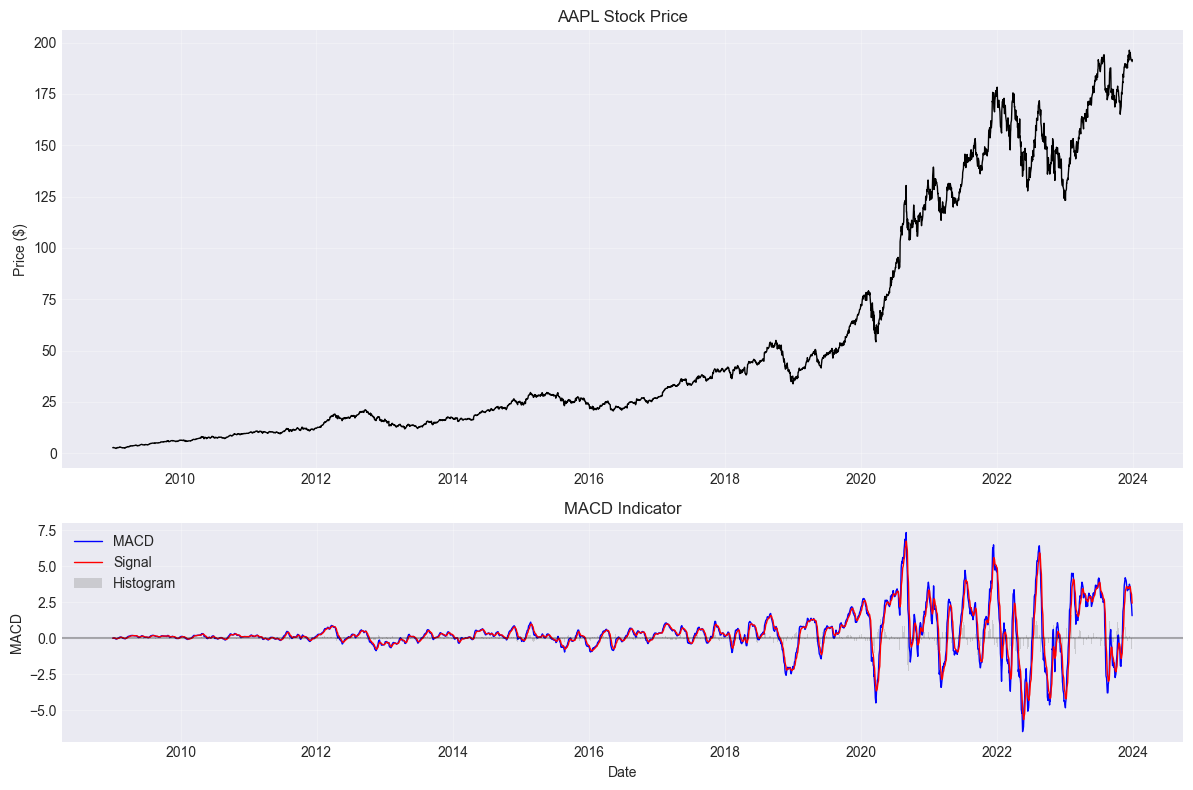

✅ MACD plot saved


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1])

ax1.plot(aapl['Date'], aapl['Close'], color='black', linewidth=1)
ax1.set_ylabel('Price ($)')
ax1.set_title('AAPL Stock Price')
ax1.grid(True, alpha=0.3)

ax2.plot(aapl['Date'], aapl['MACD'], label='MACD', color='blue', linewidth=1)
ax2.plot(aapl['Date'], aapl['Signal'], label='Signal', color='red', linewidth=1)
ax2.bar(aapl['Date'], aapl['Histogram'], color='gray', alpha=0.3, label='Histogram')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.set_xlabel('Date')
ax2.set_ylabel('MACD')
ax2.set_title('MACD Indicator')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/macd_indicator.png', dpi=150)
plt.show()
print("✅ MACD plot saved")

In [11]:
print("\n" + "="*60)
print("TASK 2 COMPLETED")
print("="*60)
print(f"\n📊 SUMMARY:")
print(f"   SMA: {'BULLISH' if latest['SMA_20'] > latest['SMA_50'] else 'BEARISH'}")
print(f"   RSI: {aapl['RSI_14'].iloc[-1]:.1f}")
print(f"   MACD: {'BULLISH' if aapl['MACD'].iloc[-1] > aapl['Signal'].iloc[-1] else 'BEARISH'}")
print("\n✅ All indicators saved to 'plots/' folder")


TASK 2 COMPLETED

📊 SUMMARY:
   SMA: BULLISH
   RSI: 40.2
   MACD: BEARISH

✅ All indicators saved to 'plots/' folder
